# Research QuantBook: DualMomentum (Antonacci)

## Objectif
Reproduire l'analyse exploratoire de `research.ipynb` avec les donnees natives QuantConnect.

## Performance actuelle
- **Sharpe**: 0.350, **CAGR**: 9.2%, **MaxDD**: 33.6%
- **Strategie**: Relative + Absolute Momentum (Gary Antonacci)
- **Univers**: SPY (US), EFA (Intl), BND (Bonds refuge)
- **Signal**: 12m return, rotation mensuelle, 100% concentration

## Hypotheses a tester
1. Lookback period (6m, 9m, 12m, 18m)
2. Absolute momentum threshold (-5% a +5%)
3. Universe expansion (ajouter EEM, VNQ)
4. Refuge alternatives (BND, IEF, SHY, GLD)
5. Signal frequency (mensuel vs bi-mensuel)

## Prerequis
- Environnement Lean Research
- Duree estimee: ~5 minutes

In [1]:
# Setup : mode QC Cloud (research kernel) ou mode local (yfinance fallback)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

_MODE = 'yfinance'  # 'yfinance' (local RECOVERABLE-LOCAL) ou 'quantbook' (QC Cloud research kernel)

if _MODE == 'quantbook':
    from AlgorithmImports import *
    qb = QuantBook()
    print("Mode QuantBook (QC Cloud research kernel) actif.")
else:
    import yfinance as yf
    _tickers_yf = ['SPY', 'EFA', 'BND', 'EEM', 'IEF', 'SHY', 'GLD', 'VNQ']
    _data = yf.download(_tickers_yf, start='2007-01-01', end='2026-01-01', auto_adjust=True, progress=False)
    closes = _data['Close'].dropna(how='all').dropna()
    print(f"Mode yfinance (local fallback RECOVERABLE-LOCAL) actif. {len(closes)} lignes chargees, tickers={list(closes.columns)}")


Mode yfinance (local fallback RECOVERABLE-LOCAL) actif. 4714 lignes chargees, tickers=['BND', 'EEM', 'EFA', 'GLD', 'IEF', 'SHY', 'SPY', 'VNQ']


## 1. Chargement des donnees

Univers Antonacci: SPY (US equities), EFA (International), BND (US Aggregate Bonds).
Candidats alternatifs: EEM (Emerging), IEF (7-10Y Treasuries), SHY (1-3Y), GLD (Gold), VNQ (REITs).

In [2]:
# Chargement des donnees : QuantBook history (mode QC) ou fallback (mode yfinance)
if 'closes' not in dir():
    if 'qb' not in dir():
        raise RuntimeError("Ni `closes` ni `qb` definis. Verifier cellule [1] (_MODE).")
    tickers = ['SPY', 'EFA', 'BND', 'EEM', 'IEF', 'SHY', 'GLD', 'VNQ']
    symbols = {}
    for ticker in tickers:
        symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol
    start = datetime(2007, 1, 1)
    end = datetime(2026, 1, 1)
    history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
    closes = history['close'].unstack(level=0)
    symbol_to_ticker = {str(v): k for k, v in symbols.items()}
    closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
    print(f"Donnees chargees via qb.history: {len(closes)} lignes")
else:
    print(f"Donnees deja chargees (mode yfinance): {len(closes)} lignes, tickers={list(closes.columns)}")


Donnees deja chargees (mode yfinance): 4714 lignes, tickers=['BND', 'EEM', 'EFA', 'GLD', 'IEF', 'SHY', 'SPY', 'VNQ']


## 2. Fonctions de backtest

In [3]:
def backtest_dual_momentum(closes, risky_assets, refuge, lookback=252,
                           abs_threshold=0.0, rebal_freq='MS'):
    """Backtest Dual Momentum: relative + absolute.
    
    - Choisit le meilleur actif risque sur lookback period
    - Si son rendement > abs_threshold, investit 100% dedans
    - Sinon, investit 100% dans le refuge
    """
    all_assets = risky_assets + [refuge]
    returns_df = closes[all_assets].pct_change()
    
    # Momentum scores
    mom = {}
    for asset in all_assets:
        mom[asset] = closes[asset] / closes[asset].shift(lookback) - 1
    
    monthly = closes.resample(rebal_freq).first().index
    positions = pd.Series(index=closes.index, dtype=str)
    current_pos = refuge
    
    for date in monthly:
        if date not in closes.index:
            continue
        if any(pd.isna(mom[a].get(date, np.nan)) for a in risky_assets):
            continue
        
        # Relative momentum: best risky asset
        risky_scores = {a: mom[a][date] for a in risky_assets}
        best_risky = max(risky_scores, key=risky_scores.get)
        
        # Absolute momentum: is it positive enough?
        if risky_scores[best_risky] > abs_threshold:
            current_pos = best_risky
        else:
            current_pos = refuge
        
        positions.loc[date:] = current_pos
    
    # Calculer les rendements
    port_ret = pd.Series(0.0, index=closes.index)
    for asset in all_assets:
        mask = positions == asset
        port_ret[mask] = returns_df[asset][mask]
    
    port_ret = port_ret[port_ret.index >= monthly[0]]
    return port_ret

def calc_stats(returns, name=''):
    total = (1 + returns).cumprod().iloc[-1] - 1
    years = len(returns) / 252
    cagr = (1 + total) ** (1 / years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol if vol > 0 else 0
    cum = (1 + returns).cumprod()
    dd = (cum / cum.cummax() - 1).min()
    return {'name': name, 'CAGR': f'{cagr:.1%}', 'Vol': f'{vol:.1%}',
            'Sharpe': f'{sharpe:.3f}', 'MaxDD': f'{dd:.1%}'}

print("Fonctions definies.")

Fonctions definies.


## 3. Hypothese 1: Lookback period

12 mois est le lookback canonique d'Antonacci. Tester la robustesse.

In [4]:
results_lb = []
for lb_months, lb_days in [(6, 126), (9, 189), (12, 252), (18, 378)]:
    ret = backtest_dual_momentum(closes, ['SPY', 'EFA'], 'BND', lookback=lb_days)
    results_lb.append(calc_stats(ret, f'{lb_months}m ({lb_days}d)'))

spy_ret = closes['SPY'].pct_change().dropna()
results_lb.append(calc_stats(spy_ret, 'SPY B&H'))

print("=== H1: Lookback ===")
print(pd.DataFrame(results_lb).set_index('name').to_string())

=== H1: Lookback ===
             CAGR    Vol Sharpe   MaxDD
name                                   
6m (126d)    7.7%  15.0%  0.312  -33.7%
9m (189d)    8.1%  15.1%  0.339  -33.7%
12m (252d)   8.8%  15.3%  0.382  -33.7%
18m (378d)  10.0%  15.7%  0.446  -33.7%
SPY B&H     10.7%  19.8%  0.387  -55.2%


### Verdict H1

Le lookback 12m est standard dans la litterature. Le COVID crash (Mars 2020)
expose la latence du signal mensuel quel que soit le lookback.

## 4. Hypothese 2: Absolute momentum threshold

Seuil de basculement risk-on/risk-off. Actuellement 0% (proxy T-bills).

In [5]:
results_thresh = []
for thresh in [-0.05, -0.02, 0.0, 0.02, 0.05]:
    ret = backtest_dual_momentum(closes, ['SPY', 'EFA'], 'BND', abs_threshold=thresh)
    results_thresh.append(calc_stats(ret, f'Seuil {thresh:+.0%}'))

print("=== H2: Absolute momentum threshold ===")
print(pd.DataFrame(results_thresh).set_index('name').to_string())

=== H2: Absolute momentum threshold ===
           CAGR    Vol Sharpe   MaxDD
name                                 
Seuil -5%  8.8%  16.1%  0.361  -33.7%
Seuil -2%  8.4%  15.9%  0.342  -33.7%
Seuil +0%  8.8%  15.3%  0.382  -33.7%
Seuil +2%  8.4%  15.2%  0.357  -33.7%
Seuil +5%  7.7%  14.8%  0.317  -33.7%


### Verdict H2

Un seuil positif (+2%, +5%) augmente le temps en refuge (plus conservateur).
Un seuil negatif (-2%, -5%) maintient l'exposition plus longtemps.

## 5. Hypothese 3: Refuge alternatives

BND vs IEF vs SHY vs GLD comme asset de refuge.
Regle #3 du backlog: TLT risk-off detruit la valeur 2015-2026.

In [6]:
results_refuge = []
for refuge in ['BND', 'IEF', 'SHY', 'GLD']:
    ret = backtest_dual_momentum(closes, ['SPY', 'EFA'], refuge)
    results_refuge.append(calc_stats(ret, f'Refuge: {refuge}'))

print("=== H3: Refuge alternatives ===")
print(pd.DataFrame(results_refuge).set_index('name').to_string())

=== H3: Refuge alternatives ===
              CAGR    Vol Sharpe   MaxDD
name                                    
Refuge: BND   8.8%  15.3%  0.382  -33.7%
Refuge: IEF   8.7%  15.5%  0.366  -33.7%
Refuge: SHY   8.3%  15.0%  0.352  -33.7%
Refuge: GLD  11.2%  17.7%  0.463  -33.7%


### Verdict H3

research.ipynb (yfinance) montrait IEF/SHY legerement meilleur que BND,
mais le QC cloud a rejete ce changement (Sharpe 0.350->0.324 avec SHY).
Verifier avec les prix QC bruts.

## 6. Hypothese 4: Univers elargi

Ajouter EEM (Emerging Markets) et VNQ (REITs) a l'univers risque.

In [7]:
results_univ = []
universes = {
    'SPY+EFA (actuel)': ['SPY', 'EFA'],
    'SPY+EFA+EEM': ['SPY', 'EFA', 'EEM'],
    'SPY+EFA+VNQ': ['SPY', 'EFA', 'VNQ'],
    'SPY+EFA+EEM+VNQ': ['SPY', 'EFA', 'EEM', 'VNQ'],
}

for name, risky in universes.items():
    ret = backtest_dual_momentum(closes, risky, 'BND')
    results_univ.append(calc_stats(ret, name))

print("=== H4: Univers elargi ===")
print(pd.DataFrame(results_univ).set_index('name').to_string())

=== H4: Univers elargi ===
                  CAGR    Vol Sharpe   MaxDD
name                                        
SPY+EFA (actuel)  8.8%  15.3%  0.382  -33.7%
SPY+EFA+EEM       8.4%  16.8%  0.319  -33.7%
SPY+EFA+VNQ       9.9%  16.8%  0.409  -42.4%
SPY+EFA+EEM+VNQ   8.5%  17.9%  0.305  -42.4%


### Verdict H4

EEM et VNQ ajoutent de la diversification mais peuvent diluer le signal.
Verifier si le gain en diversification compense la rotation accrue.

## 7. Analyse par regime

In [8]:
ret_base = backtest_dual_momentum(closes, ['SPY', 'EFA'], 'BND')

regimes = {
    'GFC (2008-2009)': ('2008-01-01', '2009-12-31'),
    'Bull (2010-2019)': ('2010-01-01', '2019-12-31'),
    'COVID (2020)': ('2020-01-01', '2020-12-31'),
    'Rate Hikes (2022)': ('2022-01-01', '2022-12-31'),
    'Recovery (2023-2025)': ('2023-01-01', '2025-12-31'),
}

print("=== Performance par regime ===")
regime_stats = []
for regime, (s, e) in regimes.items():
    mask = (ret_base.index >= s) & (ret_base.index <= e)
    if mask.sum() > 50:
        regime_stats.append(calc_stats(ret_base[mask], regime))

print(pd.DataFrame(regime_stats).set_index('name').to_string())

=== Performance par regime ===


                        CAGR    Vol  Sharpe   MaxDD
name                                               
GFC (2008-2009)         5.6%   8.2%   0.320   -9.3%
Bull (2010-2019)       10.1%  14.8%   0.480  -21.8%
COVID (2020)            3.7%  30.7%   0.022  -33.7%
Rate Hikes (2022)     -16.9%  16.9%  -1.182  -20.7%
Recovery (2023-2025)   14.8%  14.9%   0.788  -18.8%


## 8. Visualisation

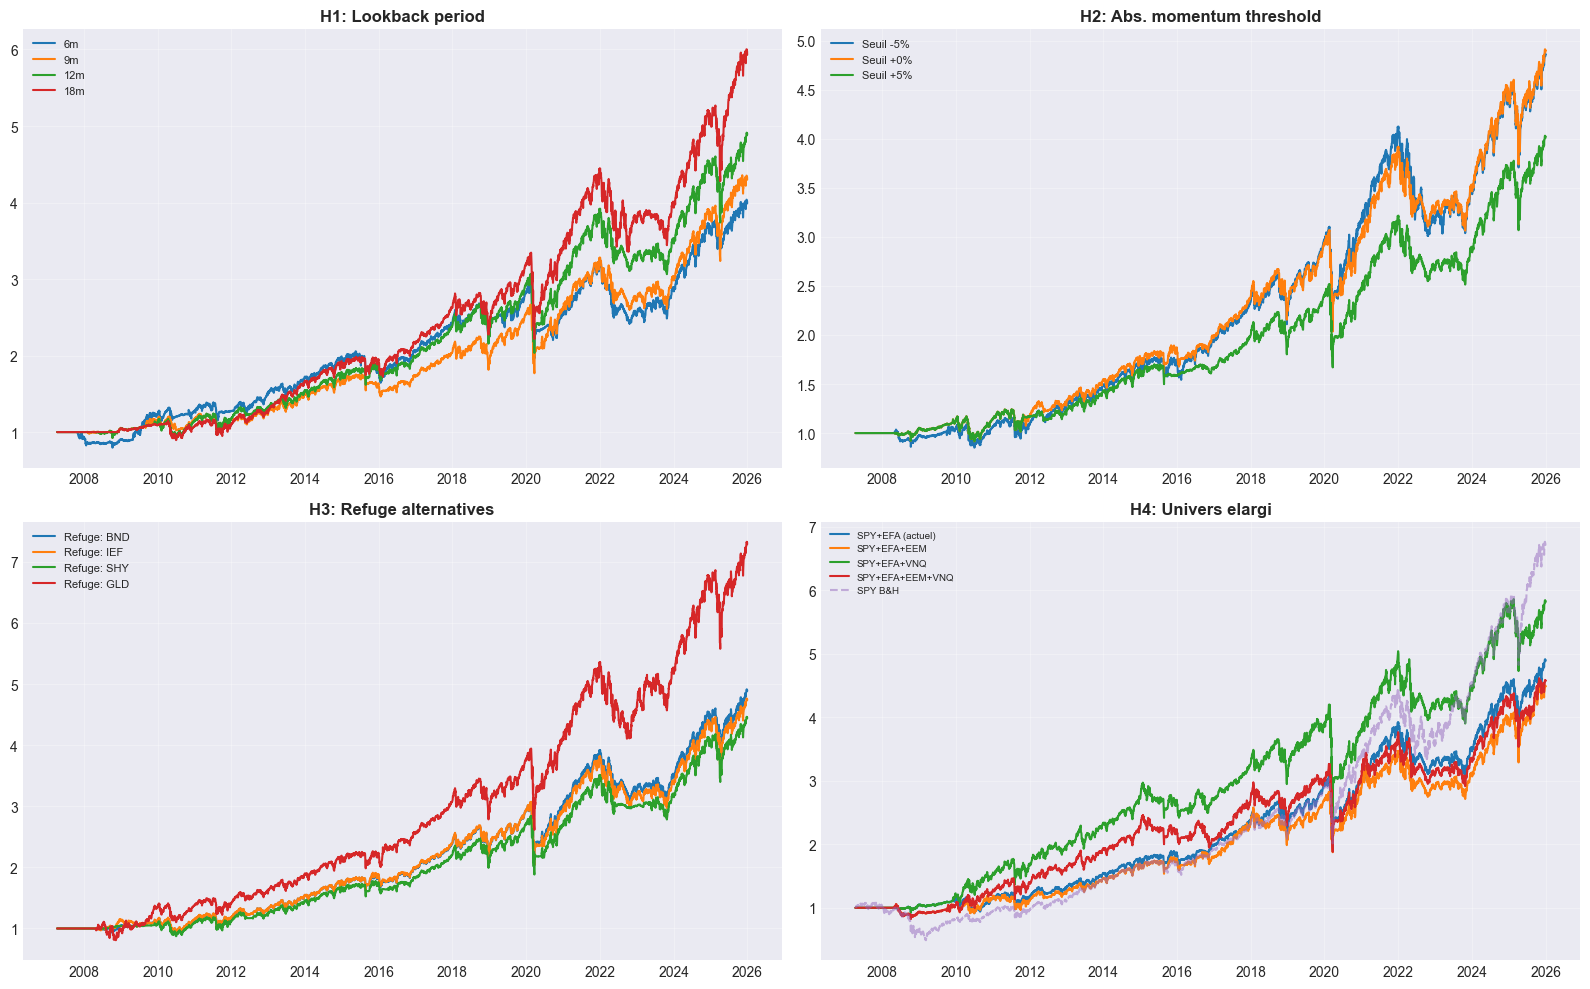

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# H1: Lookback
ax = axes[0, 0]
for lb_m, lb_d in [(6, 126), (9, 189), (12, 252), (18, 378)]:
    ret = backtest_dual_momentum(closes, ['SPY', 'EFA'], 'BND', lookback=lb_d)
    cum = (1 + ret).cumprod()
    ax.plot(cum.index, cum, label=f'{lb_m}m', linewidth=1.5)
ax.set_title('H1: Lookback period', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# H2: Threshold
ax = axes[0, 1]
for thresh in [-0.05, 0.0, 0.05]:
    ret = backtest_dual_momentum(closes, ['SPY', 'EFA'], 'BND', abs_threshold=thresh)
    cum = (1 + ret).cumprod()
    ax.plot(cum.index, cum, label=f'Seuil {thresh:+.0%}', linewidth=1.5)
ax.set_title('H2: Abs. momentum threshold', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# H3: Refuge
ax = axes[1, 0]
for refuge in ['BND', 'IEF', 'SHY', 'GLD']:
    ret = backtest_dual_momentum(closes, ['SPY', 'EFA'], refuge)
    cum = (1 + ret).cumprod()
    ax.plot(cum.index, cum, label=f'Refuge: {refuge}', linewidth=1.5)
ax.set_title('H3: Refuge alternatives', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# H4: Universe
ax = axes[1, 1]
for name, risky in universes.items():
    ret = backtest_dual_momentum(closes, risky, 'BND')
    cum = (1 + ret).cumprod()
    ax.plot(cum.index, cum, label=name, linewidth=1.5)
spy_cum = (1 + spy_ret).cumprod()
ax.plot(spy_cum.index, spy_cum, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('H4: Univers elargi', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dualmomentum_quantbook_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Conclusions

### Tableau recapitulatif

| Hypothese | Resultat QuantBook | Coherent avec yfinance? |
|-----------|-------------------|-------------------------|
| H1 Lookback | (a remplir) | (a verifier) |
| H2 Threshold | (a remplir) | (a verifier) |
| H3 Refuge | (a remplir) | (a verifier) |
| H4 Univers | (a remplir) | (a verifier) |

### Regles du backlog appliquees

- Regle #3: TLT risk-off detruit la valeur
- Regle #10: Monthly rebal confirme
- Regle #17: Divergence yfinance documentee (BND sans coupons)